In [19]:
import os
from scipy.io import wavfile
import pandas as pd
import numpy as np

Load data

In [20]:
# Define the root folder containing all subfolders
root_folder = "task1/training"

# Prepare a list to store data
data = []

# Walk through all subfolders and files
for subdir, _, files in os.walk(root_folder):
    for file in files:
        if file.endswith('.wav'):
            filepath = os.path.join(subdir, file)
            sample_rate, audio = wavfile.read(filepath)
            # Store subfolder name for reference
            subfolder = os.path.basename(subdir)
            data.append({
                'filename': file,
                'patient_id': file.split('_')[0],
                'exercise': subfolder,
                'sample_rate': sample_rate,
                'audio': audio
            })

# Create a DataFrame
df = pd.DataFrame(data)

# Show the first few rows
df.head()

,filename,patient_id,exercise,sample_rate,audio
0,ID000_phonationA.wav,ID000,phonationA,8000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,ID001_phonationA.wav,ID001,phonationA,8000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,ID002_phonationA.wav,ID002,phonationA,8000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,ID003_phonationA.wav,ID003,phonationA,8000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,ID005_phonationA.wav,ID005,phonationA,8000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [21]:
# Load the Excel file with patient info
excel_path = "task1/sand_task_1.xlsx"
patient_info = pd.read_excel(excel_path, usecols=["ID", "Age", "Sex", "Class"], engine="openpyxl")

# Merge patient info into your main DataFrame
df = df.merge(patient_info, left_on="patient_id", right_on="ID", how="left")

# Drop the redundant 'ID' column if desired
df = df.drop(columns=["ID"])

# Show the updated DataFrame
df.head()

,filename,patient_id,exercise,sample_rate,audio,Age,Sex,Class
0,ID000_phonationA.wav,ID000,phonationA,8000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",80,M,5
1,ID001_phonationA.wav,ID001,phonationA,8000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",61,F,5
2,ID002_phonationA.wav,ID002,phonationA,8000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",51,F,4
3,ID003_phonationA.wav,ID003,phonationA,8000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",59,M,3
4,ID005_phonationA.wav,ID005,phonationA,8000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",80,F,5


Select test patients

In [22]:
with open("excluded_patient_ids.txt", "r") as file:
    excluded_ids = [line.strip() for line in file]

df_test = df[df['patient_id'].isin(excluded_ids)]
df_train = df[~df['patient_id'].isin(excluded_ids)]

Define the preprocessing pipeline

In [23]:
import numpy as np
from scipy.interpolate import interp1d
import joblib
from collections import Counter

def augment_with_chunks_and_filter(x, reduce_ratio=0.4, n_chunk=25, rms_threshold=25, rng=None):
    """
    Create multiple augmented versions for each (patient, exercise),
    then filter out chunks whose max(abs) <= threshold.
    Ensures all chunks have the same fixed length.

    Parameters
    ----------
    x : ndarray, shape (n_pz, n_ex, max_t)
    reduce_ratio : float
    n_chunk : int
    threshold : float
    rng : np.random.Generator or None

    Returns
    -------
    kept_chunks : list of list of lists
        kept_chunks[i][j] is a list of arrays, each shape (target_len,)
        corresponding to significant chunks for patient i, exercise j.
    """
    if rng is None:
        rng = np.random.default_rng()

    n_pz, n_ex, time_len = x.shape
    target_len = int(np.ceil(reduce_ratio * time_len))  # fixed length for all chunks

    kept_chunks = [[[] for _ in range(n_ex)] for _ in range(n_pz)]

    for c in range(n_chunk):
        # Random start indices, ensuring the chunk fits entirely
        starts = rng.integers(0, time_len - target_len + 1, size=(n_pz, n_ex))
        for i in range(n_pz):
            for j in range(n_ex):
                s = starts[i, j]
                chunk = x[i, j, s:s + target_len]  # fixed length
                if (np.mean(np.abs(chunk)))**0.5 > rms_threshold:
                    kept_chunks[i][j].append(chunk)

    return kept_chunks


def test_preprocess_and_predict(
    df_test,
    exercise_list,
    trained_scaler_path="models/X_rhythm_scaler.pkl",
    model=None,              # trained NN model
    reduce_ratio=0.4,
    n_chunk=25,
    rms_threshold=10,
    f_max=4000,
    smooth_dim=200,
    fs=None
):
    """
    Preprocess test data the same way as training and predict per patient.
    
    Returns:
        patient_ids : list of patient IDs
        patient_predictions : np.ndarray of predicted class per patient (mode over chunks)
    """
    
    if fs is None:
        fs = df_test['sample_rate'].iloc[0]

    # === 1. Load data into matrix ===
    print("Loading data...")
    df_rhythm = df_test[df_test['exercise'].isin(exercise_list)].reset_index(drop=True)
    patient_ids = df_rhythm['patient_id'].unique()
    n_pz = len(patient_ids)
    n_ex = len(exercise_list)
    max_t = int(15 * fs)  # same as training
    print(f"n_pz: {n_pz}")

    data_matrix = np.zeros((n_pz, n_ex, max_t))
    patient_id_to_index = {pid: idx for idx, pid in enumerate(patient_ids)}
    exercise_to_index = {ex: idx for idx, ex in enumerate(exercise_list)}

    for _, row in df_rhythm.iterrows():
        pid_idx = patient_id_to_index[row['patient_id']]
        ex_idx = exercise_to_index[row['exercise']]
        audio = np.array(row['audio'])
        end = min(len(audio), max_t)
        data_matrix[pid_idx, ex_idx, :end] = audio[:end]

    # === 2. Augmentation: random chunks ===
    print("Augmenting data...")
    augmented_chunks = augment_with_chunks_and_filter(
        data_matrix, reduce_ratio=reduce_ratio, n_chunk=n_chunk, rms_threshold=rms_threshold
    )

    # === 3. FFT, frequency mask, interpolation ===
    print("Performing Fourier Analysis...")
    n_pz = len(augmented_chunks)
    fft_chunks_smooth = [[[] for _ in range(n_ex)] for _ in range(n_pz)]
    for i in range(n_pz):
        for j in range(n_ex):
            for chunk in augmented_chunks[i][j]:
                fft_chunk = np.abs(np.fft.rfft(chunk))
                freq = np.fft.rfftfreq(len(chunk), d=1/fs)
                f_mask = freq <= f_max
                fft_chunk = fft_chunk[f_mask]
                f = interp1d(freq[f_mask], fft_chunk, kind='quadratic', fill_value="extrapolate")
                fft_chunks_smooth[i][j].append(f(np.linspace(0, f_max, smooth_dim)))

    # === 4. Flatten: concatenate exercises per chunk ===
    print("Preparing data for inference...")
    X_list = []
    patient_chunk_map = []  # track which patient each row belongs to
    for i in range(n_pz):
        n_chunks_patient = min(len(fft_chunks_smooth[i][j]) for j in range(n_ex))
        if n_chunks_patient == 0:
            continue
        for c in range(n_chunks_patient):
            sample = np.concatenate([fft_chunks_smooth[i][j][c] for j in range(n_ex)])
            X_list.append(sample)
            patient_chunk_map.append(i)  # map row to patient index

    if len(X_list) == 0:
        print("No valid chunks, returning empty array")
        return patient_ids, np.array([])  # no valid chunks

    X = np.stack(X_list, axis=0)

    # === 5. Standardize using training scaler ===
    print("Loading scaler...")
    scaler = joblib.load(trained_scaler_path)
    X_scaled = scaler.transform(X)

    # === 6. Predict per chunk ===
    print("Performing classification...")
    chunk_preds = model.predict(X_scaled)  # shape (n_chunks_total, n_cl)
    chunk_labels = np.argmax(chunk_preds, axis=1)

    # === 7. Aggregate per patient using mode ===
    print("Formatting output...")
    patient_predictions = []
    for i in range(n_pz):
        # get all chunk labels for this patient
        labels_i = chunk_labels[np.array(patient_chunk_map) == i]
        if len(labels_i) == 0:
            patient_predictions.append(-1)  # no valid chunks
        else:
            # mode
            patient_predictions.append(Counter(labels_i).most_common(1)[0][0])
    print("Done!")
    return patient_ids, np.array(patient_predictions)


Load the NN and try it

In [24]:
from tensorflow.keras.models import load_model

# ====== Load models ======
NN_rhythm_categorical_1_5 = load_model('models/NN_rhythm_categorical_1_5.keras')

# Load scalers
scaler = joblib.load("models/X_rhythm_scaler.pkl")

In [25]:
max_time = 15 # Mazimum time to read in exercises, s
fs = df_train['sample_rate'].iloc[0]
exercise_list = []
n_cl = 5
for ex in df_train['exercise'].unique():
    if 'rhythm' in ex.lower():  # Select only rhythm exercises
        exercise_list.append(ex)
        
patients, y_pred = test_preprocess_and_predict(df_train,
                                               exercise_list=exercise_list,
                                               trained_scaler_path="models/X_rhythm_scaler.pkl",
                                               model = NN_rhythm_categorical_1_5,
                                               fs=fs)

# Map patient ID → class
patient_to_class = dict(zip(df_train['patient_id'], df_train['Class'] - 1))  # zero-indexed

# Build y_true in the same order as `patients`
y_true = np.array([patient_to_class[pid] for pid in patients], dtype=int)


Loading data...
n_pz: 219
Augmenting data...
Performing Fourier Analysis...
Preparing data for inference...
Loading scaler...
Performing classification...
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Formatting output...
Done!


F1 score: 0.6303220375801021


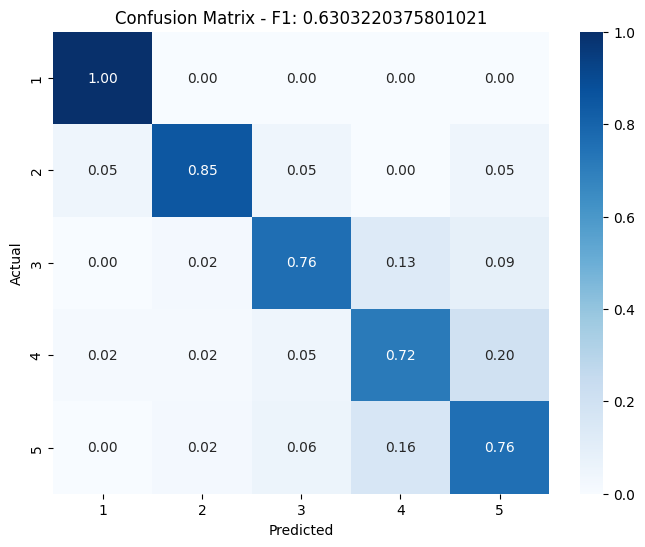

In [26]:
from sklearn.metrics import confusion_matrix, f1_score
import seaborn as sns
# Compute the f1 score
f1 = f1_score(y_true, y_pred, average='macro')
print('F1 score:', f1)

# Create the confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=range(n_cl), normalize='true')

# Plot the confusion matrix
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', xticklabels=range(1,n_cl+1), yticklabels=range(1,n_cl+1))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - F1: {f1}')
plt.show()

In [27]:
max_time = 15 # Mazimum time to read in exercises, s
fs = df_test['sample_rate'].iloc[0]
exercise_list = []
n_cl = 5
for ex in df_test['exercise'].unique():
    if 'rhythm' in ex.lower():  # Select only rhythm exercises
        exercise_list.append(ex)
        
patients, y_pred = test_preprocess_and_predict(df_test,
                                               exercise_list=exercise_list,
                                               trained_scaler_path="models/X_rhythm_scaler.pkl",
                                               model = NN_rhythm_categorical_1_5,
                                               fs=fs)

# Map patient ID → class
patient_to_class = dict(zip(df_test['patient_id'], df_test['Class'] - 1))  # zero-indexed

# Build y_true in the same order as `patients`
y_true = np.array([patient_to_class[pid] for pid in patients], dtype=int)

Loading data...
n_pz: 53
Augmenting data...
Performing Fourier Analysis...
Preparing data for inference...
Loading scaler...
Performing classification...
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Formatting output...
Done!


F1 score: 0.2042069944508969


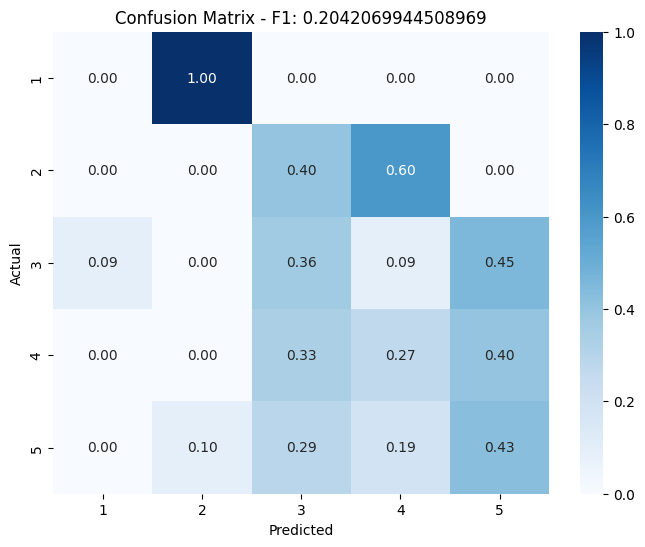

In [28]:
from sklearn.metrics import confusion_matrix, f1_score
import seaborn as sns
# Compute the f1 score
f1 = f1_score(y_true, y_pred, average='macro')
print('F1 score:', f1)

# Create the confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=range(n_cl), normalize='true')

# Plot the confusion matrix
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', xticklabels=range(1,n_cl+1), yticklabels=range(1,n_cl+1))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - F1: {f1}')
plt.show()